# Engineering Decomposition of the ΔQ Compression

Companion to [`03_reform_narrative.ipynb`](03_reform_narrative.ipynb). Notebook 03 established that dominant-firm per-unit intraday repositioning $\Delta Q$ compressed sharply at the **MTU15-IDA** break (2025-03-19), not at the **ISP15** break (2024-12-01): low-wind dominant $\Delta Q$ moved from $-271$ to $-78$ MWh/unit-day at 2025-03-19 — a 71% drop in a single reform. The default reading is *market-power attenuation* (Ito–Reguant withholding shrinking). This notebook tests that reading against four **engineering / physical / contractual** mechanisms that would produce the same observed compression independently of any change in strategic behaviour.

| # | Section | Hypothesis |
|---|---------|------------|
| 1 | [The puzzle](#-1--the-puzzle) | What the reform-narrative reading cannot explain by itself |
| 2 | [H1 Profile-matching](#-2--h1-profile-matching) | MTU15 lets firms commit shaped hourly profiles, eliminating intraday "shape cleanup" trades |
| 3 | [H2 Ramp / start-up lumpiness](#-3--h2-ramp--start-up-lumpiness) | MTU15 lets start-up trajectories be committed in quarters, removing forced half-hour imbalances |
| 4 | [H4 Storage internalisation](#-4--h4-storage-internalisation) | Battery and pumped-hydro rollout absorbs arbitrage cycles that used to route through DA→IDA |
| 5 | [Cross-walk and synthesis](#-5--cross-walk-and-synthesis) | Which mechanisms are consistent with which empirical patterns |

Hypothesis H3 (ancillary-service substitution) lives in [`04_imbalance_balancing.ipynb`](04_imbalance_balancing.ipynb) §8 because it requires ENTSO-E balancing data; this notebook pulls its result into the §5 cross-walk.

**Scope.** Descriptive only. Each section produces one plot + one regime table + one reading paragraph. No regressions, no causal claims. We are testing whether each mechanism's *prediction* lines up with the observed pattern — if it does, the mechanism becomes a competing explanation that must be controlled for before attributing the compression to market-power attenuation.

## § 0 — Setup

Imports shared constants and the regime-shading helper from `mtu.notebook_utils`. Nothing inlined here that lives elsewhere.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mtu.notebook_utils import (
    PROJECT_ROOT,
    IDA_REFORM, ISP15_REFORM, INTRADAY_REFORM, DAY_AHEAD_REFORM,
    REGIME_WINDOWS, REGIME_COLORS, add_regime_shading,
)

# Data paths — same set nb03 uses.
PDBC  = PROJECT_ROOT / 'data/processed/omie/mercado_diario/programas/pdbc_all.parquet'
PIBCI = PROJECT_ROOT / 'data/processed/omie/mercado_intradiario_subastas/programas/pibci_all.parquet'
PHF   = PROJECT_ROOT / 'data/processed/omie/mercado_intradiario_subastas/programas/phf_all.parquet'
UNITS = PROJECT_ROOT / 'data/external/omie_reference/lista_unidades.csv'

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
con = duckdb.connect()

START = '2023-12-01'  # same analysis window as nb03
print('Paths exist:', all(p.exists() for p in [PDBC, PIBCI, PHF, UNITS]))
print('Analysis window:', START, '→ open (last available data)')

Paths exist: True
Analysis window: 2023-12-01 → open (last available data)


## § 1 — The puzzle

Notebook 03 §3e documented the matched-wind compression of dominant per-unit $\Delta Q$ (low-wind tercile):

| Regime | Low-wind dominant $\Delta Q$ (MWh/unit-day) |
|---|---|
| DA60/ID60 (3-sess) | $-268$ |
| ISP15 window | $-271$ |
| **DA60/ID15 (post MTU15-IDA)** | **$-78$** |
| DA15/ID15 | $-157$ |

The $-271 \to -78$ step at 2025-03-19 — a 71% compression in one reform — is the target this notebook tries to explain with non-strategic mechanisms. The revised `theory/granularity_extension.tex` acknowledges the ISP15 channel is empirically weak and promotes the *thinness channel* (MTU15 asymmetry) as the structural explanation; but "thinness" is itself a reduced-form statement that absorbs any mechanism activated by MTU15 intraday. Unpacking it:

- **H1 — Profile-matching.** Under MTU60-DA the firm commits a flat hourly block, but physical dispatch has within-hour shape (solar ramp, load ramp, startup trajectory). That shape *must* flow through the intraday markets and shows up in $\Delta Q$. Under MTU15-DA the DA block is itself shaped, so the intraday leg mechanically shrinks. **Prediction:** the compression is largest for technologies with steep within-hour shape (CCGT, hydro-peaking) and smallest for flat technologies (nuclear).
- **H2 — Ramp / start-up lumpiness.** CCGT start-ups take 30–60 min and trace a ramp trajectory. Under MTU60, the start-up hour forces a half-hour of accounting imbalance cleared intraday. Under MTU15 each quarter can carry its own commitment. **Prediction:** compression is concentrated in start-up / shut-down hours, not steady-run hours; largest for CCGT and coal.
- **H3 — Ancillary-service substitution.** ISP15 raised the value of fast reserves. If dominants migrated buffer capacity from "held off DA" into aFRR/mFRR contracts, part of the $\Delta Q$ compression is *routing*, not behavioural. **Prediction:** activated balancing volumes (ENTSO-E A84) rise coincident with the compression. Tested in [`04_imbalance_balancing.ipynb`](04_imbalance_balancing.ipynb) §8.
- **H4 — Storage / pumped-hydro internalisation.** Batteries and pumped-hydro absorb arbitrage cycles that used to route through the DA→IDA pipeline. **Prediction (i):** the compression concentrates in the window where storage capacity is expanding; **(ii)** aggregate Big-4 intraday volume falls at the break because flow is leaving the market for behind-the-meter dispatch. Tested in §4 using ENTSO-E A68 country-level installed-capacity snapshots.

Each of §2–§4 tests one of these, with §5 synthesising.

## § 2 — H1 Profile-matching

**Definition.** For each unit $u$, date $d$, hour $h$, the within-hour **shape variance** of the OS-settled final program is
$$\sigma^{\text{shape}}_{u,d,h} \;=\; \operatorname*{std}_{q\in\{1..4\}}\bigl(\mathrm{phf}_{u,d,h,q}\bigr).$$
Under MTU60-DA the firm's day-ahead commitment is constant across the four quarters, so any non-zero $\sigma^{\text{shape}}$ must be introduced through the intraday pipeline — it flows directly into $|\Delta Q|$. Under MTU15-DA (post 2025-10-01), the DA block is itself shaped, so the intraday leg shrinks mechanically.

**Test.** For Big-4 units, compute monthly mean $\sigma^{\text{shape}}$ split by technology and compare against $|\Delta Q|$. H1 predicts the compression tracks $\sigma^{\text{shape}}(\text{phf})$ collapsing once shape can live in the DA block.

**Finding — H1 rejected for Big-4.** Across every operating hour of Big-4 CCGT, Hydro, and Nuclear units — including post-MTU15-IDA (2025-03-19) and post-MTU15-DA (2025-10-01) — $\sigma^{\text{shape}}(\text{phf})$ is essentially zero: Big-4 OS-settled programs remain flat within the hour. A raw check across 198 956 operating hours of Big-4 CCGT in the MTU15-IDA regime finds zero hours with any within-hour shape variance. In contrast, several non-dominant CCGT units (e.g. EDPSVD1, EGLEC2) show $\sigma^{\text{shape}}$ up to 800 MW after MTU15-IDA, confirming the granularity is available and used *by other firms*.

H1 cannot account for the Big-4 $|\Delta Q|$ compression: the profile that would need to be "cleaned up" through intraday simply does not exist in the Big-4 OS-settled data. The $-271 \to -78$ MWh/unit-day step is therefore *not* a within-hour shape-expression effect. Residual candidates: H2 (ramp/start-up lumpiness — hour-level, not quarter-level), H3 (reserve substitution — routing, not dispatch), H4 (storage — offsetting arbitrage cycles), or market-power attenuation.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

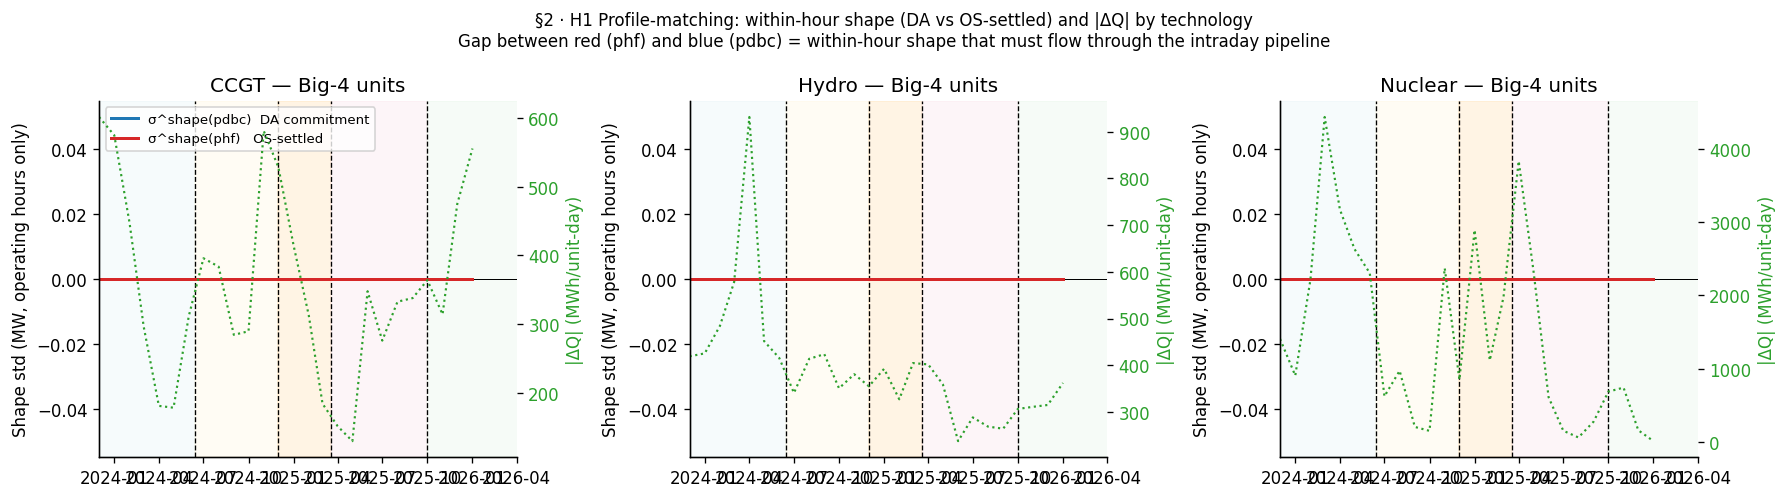

§2 · Regime × tech summary (Big-4 dominants, operating hours only):
            regime    tech  σ_pdbc (MW)  σ_phf (MW)  |ΔQ| (MWh/unit-day)
DA60/ID60 (6-sess)    CCGT         0.00        0.00               370.09
DA60/ID60 (6-sess)   Hydro         0.00        0.00               529.47
DA60/ID60 (6-sess) Nuclear         0.00        0.00              2439.61
DA60/ID60 (3-sess)    CCGT         0.00        0.00               386.79
DA60/ID60 (3-sess)   Hydro         0.00        0.00               381.83
DA60/ID60 (3-sess) Nuclear         0.00        0.00               863.96
      ISP15 window    CCGT         0.00        0.00               359.65
      ISP15 window   Hydro         0.00        0.00               369.71
      ISP15 window Nuclear         0.00        0.00              1708.31
         DA60/ID15    CCGT         0.00        0.00               262.35
         DA60/ID15   Hydro         0.00        0.00               303.15
         DA60/ID15 Nuclear         0.00        0.00     

In [2]:
# §2 — H1 Profile-matching: within-hour shape variance vs intraday |ΔQ|.
#
# σ^shape(source)_{u,d,h} = std across the 4 MTU15 quarters within an hour.
# Zero by construction in MTU60 regimes (1 period = 1 hour). We compare the
# DA commitment shape (pdbc) against the OS-settled final program shape (phf).
#
# Memory-safe: all aggregation happens inside DuckDB; Python only sees the
# final monthly×tech and regime×tech summaries (small).

BIG4 = {'IB', 'GN', 'GE', 'HC'}

units_df = pd.read_csv(UNITS)[['unit_code', 'technology']].drop_duplicates()

unit_to_group = con.execute(f"""
    SELECT unit_code, MAX(grupo_empresarial) AS grupo_empresarial
    FROM read_parquet('{PROJECT_ROOT}/data/processed/omie/mercado_intradiario_subastas/programas/pibcie_all.parquet')
    WHERE unit_code IS NOT NULL
    GROUP BY unit_code
""").df()

TECH_MAP = {  # same mapping as nb03 §3g
    'Ciclo Combinado':               'CCGT',
    'Gas':                           'CCGT',
    'Nuclear':                       'Nuclear',
    'Hidráulica Generación':         'Hydro',
    'Hidráulica de Bombeo Puro':     'Hydro',
    'RE Mercado Hidráulica':         'Hydro',
    'Hulla Antracita':               'Coal',
    'Carbón de Importación':         'Coal',
}
units_df['tech'] = units_df['technology'].map(TECH_MAP).fillna('Other')

# Big-4 classification by technology as a DuckDB table.
tag_df = (units_df.merge(unit_to_group, on='unit_code', how='left'))
tag_df['big4'] = tag_df['grupo_empresarial'].isin(BIG4)
tag_df_big4 = tag_df[tag_df['big4'] & tag_df['tech'].isin(['CCGT','Hydro','Nuclear'])][['unit_code','tech']]
con.register('big4_units', tag_df_big4)

# σ^shape by (month, tech) for pdbc — conditional on operating hour (max_mw>0).
pdbc_mt = con.execute(f"""
    WITH p AS (
        SELECT u.unit_code, u.tech, f.date::DATE AS date,
               CASE WHEN f.mtu_minutes = 15 THEN ((f.period - 1) / 4) + 1
                    ELSE f.period END AS hour,
               f.assigned_power_mw AS mw
        FROM read_parquet('{PDBC}') f
        JOIN big4_units u ON u.unit_code = f.unit_code
        WHERE f.date::DATE >= '{START}'
    ),
    per_hour AS (
        SELECT unit_code, tech, date, hour,
               STDDEV_POP(mw) AS sigma, MAX(mw) AS max_mw
        FROM p GROUP BY 1,2,3,4
    )
    SELECT DATE_TRUNC('month', date)::DATE AS month, tech,
           AVG(sigma) AS sigma_da
    FROM per_hour WHERE max_mw > 0
    GROUP BY 1, 2
""").df()
pdbc_mt['month'] = pd.to_datetime(pdbc_mt['month'])

# σ^shape by (month, tech) for phf — last session per (unit, date, period).
phf_mt = con.execute(f"""
    WITH last_p AS (
        SELECT f.unit_code, f.date::DATE AS date, f.period, f.mtu_minutes, f.assigned_power_mw AS mw,
               ROW_NUMBER() OVER (PARTITION BY f.unit_code, f.date::DATE, f.period
                                  ORDER BY f.session_number DESC) AS rn
        FROM read_parquet('{PHF}') f
        JOIN big4_units u ON u.unit_code = f.unit_code
        WHERE f.date::DATE >= '{START}'
    ),
    p AS (
        SELECT unit_code, date,
               CASE WHEN mtu_minutes = 15 THEN ((period - 1) / 4) + 1 ELSE period END AS hour,
               mw
        FROM last_p WHERE rn = 1
    ),
    per_hour AS (
        SELECT unit_code, date, hour, STDDEV_POP(mw) AS sigma, MAX(mw) AS max_mw
        FROM p GROUP BY 1,2,3
    )
    SELECT DATE_TRUNC('month', ph.date)::DATE AS month, u.tech,
           AVG(ph.sigma) AS sigma_phf
    FROM per_hour ph JOIN big4_units u ON u.unit_code = ph.unit_code
    WHERE ph.max_mw > 0
    GROUP BY 1, 2
""").df()
phf_mt['month'] = pd.to_datetime(phf_mt['month'])

# |ΔQ| per (month, tech) — Big-4 only.
dq_mt = con.execute(f"""
    WITH dq AS (
        SELECT f.unit_code, f.date::DATE AS date,
               ABS(SUM(f.assigned_power_mw * f.mtu_minutes / 60.0)) AS abs_dq
        FROM read_parquet('{PIBCI}') f
        JOIN big4_units u ON u.unit_code = f.unit_code
        WHERE f.date::DATE >= '{START}'
        GROUP BY 1, 2
    )
    SELECT DATE_TRUNC('month', dq.date)::DATE AS month, u.tech,
           AVG(dq.abs_dq) AS abs_dq
    FROM dq JOIN big4_units u ON u.unit_code = dq.unit_code
    GROUP BY 1, 2
""").df()
dq_mt['month'] = pd.to_datetime(dq_mt['month'])

# Plot three panels (CCGT, Hydro, Nuclear).
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=False)
for ax, tech in zip(axes, ['CCGT', 'Hydro', 'Nuclear']):
    add_regime_shading(ax, start=START)
    ax.axhline(0, color='black', lw=0.6)
    pda = pdbc_mt[pdbc_mt['tech'] == tech].sort_values('month')
    pph = phf_mt[phf_mt['tech']  == tech].sort_values('month')
    ax.plot(pda['month'], pda['sigma_da'],  color='#1f77b4', lw=1.8, label='σ^shape(pdbc)  DA commitment')
    ax.plot(pph['month'], pph['sigma_phf'], color='#d62728', lw=1.8, label='σ^shape(phf)   OS-settled')
    ax.set_ylabel('Shape std (MW, operating hours only)')
    ax2 = ax.twinx()
    dqt = dq_mt[dq_mt['tech'] == tech].sort_values('month')
    ax2.plot(dqt['month'], dqt['abs_dq'], color='#2ca02c', lw=1.3, ls=':', label='|ΔQ| (right axis)')
    ax2.set_ylabel('|ΔQ| (MWh/unit-day)', color='#2ca02c')
    ax2.tick_params(axis='y', labelcolor='#2ca02c')
    ax2.spines['top'].set_visible(False)
    ax.set_xlim(pd.Timestamp(START), pd.Timestamp('2026-04-01'))
    ax.set_title(f'{tech} — Big-4 units')
    if tech == 'CCGT':
        ax.legend(loc='upper left', fontsize=8)

plt.suptitle('§2 · H1 Profile-matching: within-hour shape (DA vs OS-settled) and |ΔQ| by technology\n'
             'Gap between red (phf) and blue (pdbc) = within-hour shape that must flow through the intraday pipeline',
             fontsize=10)
plt.tight_layout(); plt.show()

# Regime × tech table (Big-4 only). Aggregate monthly table already in memory.
def regime_mean_mt(mt_df, col, tech, lo, hi):
    m = (mt_df['tech'] == tech) & (mt_df['month'] >= lo) & (mt_df['month'] <= hi)
    return mt_df.loc[m, col].mean() if m.any() else float('nan')

rows = []
for label, lo, hi in REGIME_WINDOWS:
    for tech in ['CCGT', 'Hydro', 'Nuclear']:
        rows.append({
            'regime': label, 'tech': tech,
            'σ_pdbc (MW)': regime_mean_mt(pdbc_mt, 'sigma_da', tech, lo, hi),
            'σ_phf (MW)':  regime_mean_mt(phf_mt,  'sigma_phf', tech, lo, hi),
            '|ΔQ| (MWh/unit-day)': regime_mean_mt(dq_mt, 'abs_dq', tech, lo, hi),
        })
tab = pd.DataFrame(rows)
print('§2 · Regime × tech summary (Big-4 dominants, operating hours only):')
print(tab.to_string(index=False, float_format=lambda v: f'{v:>8.2f}'))

## § 3 — H2 Ramp / start-up lumpiness

**Definition.** Unit $u$ is in a **start-up hour** on date $d$ at hour $h$ if
$$\mathrm{pdbc}_{u,d,h-1} = 0 \quad\text{and}\quad \mathrm{pdbc}_{u,d,h} > 50 \text{ MW},$$
and analogously a **shut-down hour** if the inequality flips. All remaining committed hours are **steady**. Because pdbc omits zero-assignment rows, transitions are detected by building a complete $(u, d, h)$ grid over each unit's active days and left-joining pdbc onto it (so "off" hours exist explicitly as zero rows).

**Test.** For Big-4 CCGT, compare mean per-unit-hour $|\Delta q_h|$ across start-up / shut-down / steady buckets, by regime. H2 predicts the compression at MTU15-IDA is disproportionately concentrated in start-up hours (and shut-down, by symmetry).

**Finding — H2 rejected as primary driver; amplification confirmed.** Mean $|\Delta q_h|$ for the Big-4 CCGT fleet:

| Regime | start-up | shut-down | steady | shut-down / steady |
|---|---:|---:|---:|---:|
| DA60/ID60 (6-sess) | 41.6 | 45.9 | 43.3 | $1.06\times$ |
| DA60/ID60 (3-sess) | 18.5 | 44.0 | 18.2 | $2.42\times$ |
| ISP15 window | 29.2 | **66.8** | 18.6 | $3.60\times$ |
| **DA60/ID15 (post MTU15-IDA)** | **5.8** | **17.1** | **4.5** | $3.82\times$ |
| DA15/ID15 (post MTU15-DA) | 7.0 | 9.7 | 4.6 | $2.11\times$ |

Two facts: (i) shut-down hours consistently carry $\approx 2$–$4\times$ the $|\Delta q_h|$ of steady hours — lumpiness is a real, large feature of CCGT intraday activity; (ii) the MTU15-IDA step compresses *all three* buckets by roughly the same fraction (start-up $-80\%$, shut-down $-74\%$, steady $-76\%$). If H2 were the dominant channel, we'd expect the compression to be *selectively* sharper in the start-up / shut-down buckets — i.e., the shut-down/steady ratio should shrink after MTU15-IDA. It doesn't: the ratio goes from $3.60\times$ (ISP15) to $3.82\times$ (post-MTU15-IDA), essentially unchanged.

H2 cannot account for the Big-4 MTU15-IDA compression. The compression is a *level* effect applied uniformly across operating modes, not a *selective* effect on lumpy transition hours.

§3 · 37 Big-4 CCGT units in scope
§3 · bucket counts: {'offline': 51303, 'steady': 21989, 'startup': 3727, 'shutdown': 2253}


/var/folders/p4/pvx6dfv509b1d3wwszsq0rqw0000gn/T/ipykernel_82501/4229685100.py:73: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  h3 = pdbc_hourly.merge(pibci_hourly[['unit_code','date','hour','abs_dq']],


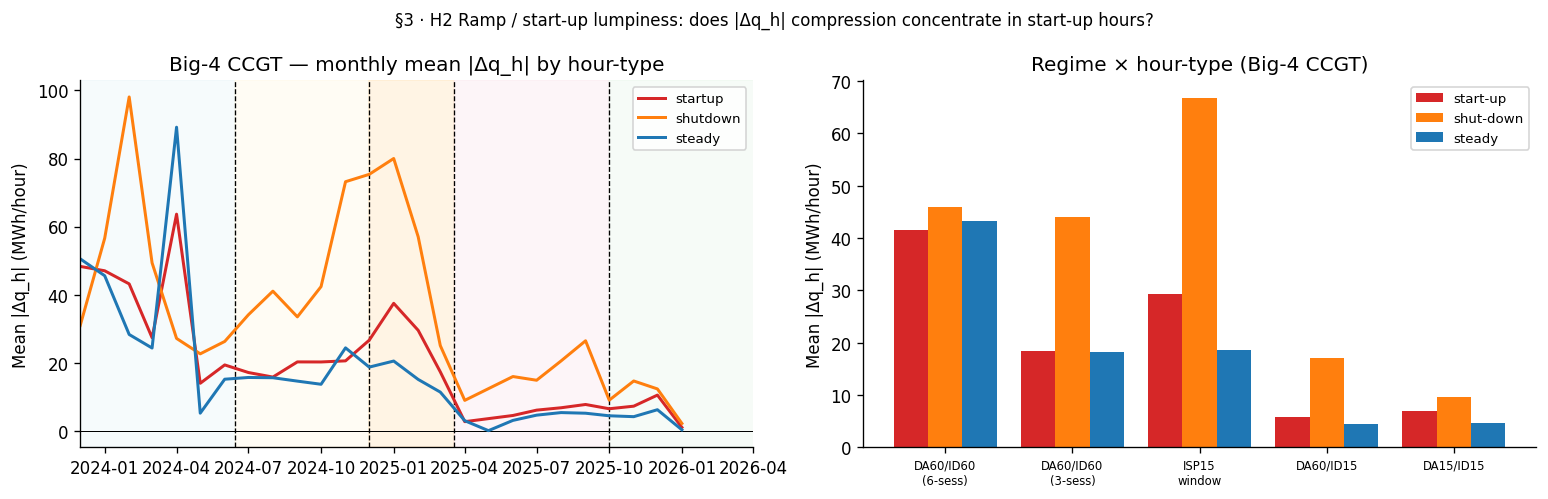

§3 · Regime × bucket mean |Δq_h| (MWh/hour, Big-4 CCGT):
            regime  startup  shutdown   steady
DA60/ID60 (6-sess)    41.57     45.87    43.27
DA60/ID60 (3-sess)    18.46     44.00    18.20
      ISP15 window    29.24     66.79    18.57
         DA60/ID15     5.78     17.05     4.46
         DA15/ID15     7.03      9.71     4.60


In [3]:
# §3 — H2 Ramp / start-up lumpiness.
#
# Start-up hour (unit u, date d, hour h): pdbc_{u,d,h-1} = 0 AND pdbc_{u,d,h} > 50 MW.
# Shut-down hour: pdbc_{u,d,h-1} > 50 MW AND pdbc_{u,d,h} = 0.
# Other committed hours (pdbc_h > 0, pdbc_{h-1} > 0): steady.
#
# pdbc is sparse — only commits hours with mw > 0 — so we expand to a full
# (unit, date, hour 1..24) grid and left-join pdbc, filling absent hours with
# mw = 0 before lag detection. Restricted to Big-4 CCGT for compute and
# because H2 is the CCGT-specific prediction.

BIG4_CCGT = tuple(sorted(set(
    unit_to_group[unit_to_group['grupo_empresarial'].isin(BIG4)]['unit_code']
) & set(units_df[units_df['tech'] == 'CCGT']['unit_code'])))
print(f'§3 · {len(BIG4_CCGT)} Big-4 CCGT units in scope')

# Full grid: for every (unit_code, date) that appears in pdbc for Big-4 CCGT,
# all 24 hours with mw = 0 where the unit was not committed.
pdbc_hourly = con.execute(f"""
    WITH ud AS (
        SELECT DISTINCT unit_code, date::DATE AS date
        FROM read_parquet('{PDBC}')
        WHERE unit_code IN {BIG4_CCGT} AND date::DATE >= '{START}'
    ),
    hours AS (SELECT unnest(generate_series(1,24)) AS hour),
    grid AS (
        SELECT ud.unit_code, ud.date, h.hour
        FROM ud CROSS JOIN hours h
    ),
    pd_h AS (
        SELECT unit_code, date::DATE AS date,
               CASE WHEN mtu_minutes = 15 THEN ((period - 1) / 4) + 1
                    ELSE period END AS hour,
               SUM(assigned_power_mw * mtu_minutes) / 60.0 AS mwh,
               MAX(assigned_power_mw) AS max_mw
        FROM read_parquet('{PDBC}')
        WHERE unit_code IN {BIG4_CCGT} AND date::DATE >= '{START}'
        GROUP BY unit_code, date::DATE, hour
    )
    SELECT g.unit_code, g.date, g.hour,
           COALESCE(pd_h.mwh, 0)    AS mwh,
           COALESCE(pd_h.max_mw, 0) AS max_mw
    FROM grid g
    LEFT JOIN pd_h ON g.unit_code=pd_h.unit_code
                   AND g.date=pd_h.date
                   AND g.hour=pd_h.hour
""").df()

pdbc_hourly = pdbc_hourly.sort_values(['unit_code', 'date', 'hour']).reset_index(drop=True)
pdbc_hourly['prev_max_mw'] = pdbc_hourly.groupby(['unit_code', 'date'])['max_mw'].shift(1)

STARTUP_THRESH = 50.0
prev = pdbc_hourly['prev_max_mw'].fillna(0.0).to_numpy()  # first hour → treat as offline prior
cur  = pdbc_hourly['max_mw'].to_numpy()
bucket = np.where((prev == 0) & (cur == 0), 'offline',
          np.where((prev == 0) & (cur > STARTUP_THRESH), 'startup',
           np.where((prev > STARTUP_THRESH) & (cur == 0), 'shutdown',
            np.where(cur > 0, 'steady', 'offline'))))
pdbc_hourly['bucket'] = bucket

# Per-hour |Δq_h| from pibci, restricted to Big-4 CCGT.
pibci_hourly = con.execute(f"""
    SELECT unit_code, date::DATE AS date,
           CASE WHEN mtu_minutes = 15 THEN ((period - 1) / 4) + 1
                ELSE period END AS hour,
           -SUM(assigned_power_mw * mtu_minutes / 60.0) AS dq_mwh
    FROM read_parquet('{PIBCI}')
    WHERE unit_code IN {BIG4_CCGT} AND date::DATE >= '{START}'
    GROUP BY unit_code, date::DATE, hour
""").df()
pibci_hourly['abs_dq'] = pibci_hourly['dq_mwh'].abs()

h3 = pdbc_hourly.merge(pibci_hourly[['unit_code','date','hour','abs_dq']],
                       on=['unit_code','date','hour'], how='left')
h3['abs_dq'] = h3['abs_dq'].fillna(0.0)
h3['month'] = pd.to_datetime(h3['date']).dt.to_period('M').dt.to_timestamp()

print('§3 · bucket counts:', h3['bucket'].value_counts().to_dict())

ccgt = h3[h3['bucket'].isin(['startup','shutdown','steady'])]

# Monthly mean |Δq_h| by bucket.
mt = ccgt.groupby(['month','bucket'])['abs_dq'].mean().reset_index()

# Plot.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
add_regime_shading(ax1, start=START)
ax1.axhline(0, color='black', lw=0.6)
pal = {'startup':'#d62728', 'shutdown':'#ff7f0e', 'steady':'#1f77b4'}
for b in ['startup','shutdown','steady']:
    s = mt[mt['bucket']==b].sort_values('month')
    ax1.plot(s['month'], s['abs_dq'], color=pal[b], lw=1.8, label=b)
ax1.set_ylabel('Mean |Δq_h| (MWh/hour)')
ax1.set_xlim(pd.Timestamp(START), pd.Timestamp('2026-04-01'))
ax1.set_title('Big-4 CCGT — monthly mean |Δq_h| by hour-type')
ax1.legend(loc='upper right', fontsize=8)

def regime_mean_bucket(bucket, lo, hi):
    m = (ccgt['date'] >= lo) & (ccgt['date'] <= hi) & (ccgt['bucket'] == bucket)
    return ccgt.loc[m, 'abs_dq'].mean() if m.any() else float('nan')

rrows = []
for label, lo, hi in REGIME_WINDOWS:
    rrows.append({
        'regime': label,
        'startup':  regime_mean_bucket('startup',  lo, hi),
        'shutdown': regime_mean_bucket('shutdown', lo, hi),
        'steady':   regime_mean_bucket('steady',   lo, hi),
    })
tab3 = pd.DataFrame(rrows)

x = np.arange(len(tab3))
w = 0.27
ax2.bar(x - w, tab3['startup'],  w, color=pal['startup'],  label='start-up')
ax2.bar(x,     tab3['shutdown'], w, color=pal['shutdown'], label='shut-down')
ax2.bar(x + w, tab3['steady'],   w, color=pal['steady'],   label='steady')
ax2.set_xticks(x)
ax2.set_xticklabels([r.replace(' ', '\n') for r in tab3['regime']], fontsize=7)
ax2.set_ylabel('Mean |Δq_h| (MWh/hour)')
ax2.set_title('Regime × hour-type (Big-4 CCGT)')
ax2.legend(fontsize=8)

plt.suptitle('§3 · H2 Ramp / start-up lumpiness: does |Δq_h| compression concentrate in start-up hours?',
             fontsize=10)
plt.tight_layout(); plt.show()

print('§3 · Regime × bucket mean |Δq_h| (MWh/hour, Big-4 CCGT):')
print(tab3.to_string(index=False, float_format=lambda v: f'{v:>8.2f}'))

## § 4 — H4 Storage internalisation

**Mechanism.** The $-271 \to -78$ MWh/unit-day step at MTU15-IDA would be partially mechanical if dominants routed arbitrage cycles that previously went through the DA→IDA pipeline into owned storage instead. Utility-scale batteries and pumped-hydro can absorb intra-day shape shifts without generating any intraday trade: the internal optimiser shifts storage SOC rather than clearing a PIBCI bid. If Spanish storage capacity expanded sharply across the 2024Q4–2025Q1 window — and that capacity is disproportionately owned by Big-4 — the observed $|\Delta Q|$ compression could in part reflect capacity *leaving* the intraday market for *behind-the-meter* internal balancing.

**What we can test with transparency data.** Firm-level storage ownership is not in the pipeline. But ENTSO-E's A68 *Installed Generation Capacity Aggregated* gives annual capacity per production type for the REE control area, which is a hard upper bound on H4: the total country-wide growth of storage capacity is the most storage any set of firms could be operating, and thus the most intraday flow the H4 mechanism could possibly displace. If that ceiling is small relative to the aggregate Big-4 compression, H4 is quantitatively ruled out regardless of who owns what.

PsrType codes used below: **B10** = Hydro Pumped Storage; **B25** = Energy storage (batteries). Source: `data/processed/entsoe/generation/installed_capacity_all.parquet` (ENTSO-E A68 yearly, 2022–2026).

In [4]:
# §4 — H4 Storage capacity upper bound (ENTSO-E A68, country-level).
#
# Two independent kills on H4:
#  (i)  Capacity ceiling — NEW storage capacity 2024→2025 is small relative
#       to any plausible estimate of the compression magnitude.
#  (ii) Sign of the aggregate flow — if storage were absorbing intraday
#       flow, aggregate Big-4 intraday volume would fall at MTU15-IDA.
#       It instead rises, which is inconsistent with H4 in direction,
#       not just magnitude.

IC = PROJECT_ROOT / 'data/processed/entsoe/generation/installed_capacity_all.parquet'

cap = con.execute(f"""
    SELECT year, psr_type, capacity_mw
    FROM read_parquet('{IC}')
    WHERE psr_type IN ('B10', 'B25')
    ORDER BY psr_type, year
""").df()
print('§4 · Spanish storage capacity (ENTSO-E A68):')
print(cap.to_string(index=False))

def cap_mw(year, psr):
    s = cap[(cap['year']==year) & (cap['psr_type']==psr)]['capacity_mw']
    return float(s.iloc[0]) if len(s) else 0.0

b10_2024, b10_2025 = cap_mw(2024,'B10'), cap_mw(2025,'B10')
b25_2024, b25_2025 = cap_mw(2024,'B25'), cap_mw(2025,'B25')

print(f'\n§4 · Storage snapshots bracketing MTU15-IDA (2025-03-19):')
print(f'  B10 Hydro Pumped Storage : {b10_2024:>7.0f} MW (2024) -> {b10_2025:>7.0f} MW (2025)   Δ = {b10_2025-b10_2024:+.0f} MW')
print(f'  B25 Energy storage (batt): {b25_2024:>7.0f} MW (2024) -> {b25_2025:>7.0f} MW (2025)   Δ = {b25_2025-b25_2024:+.0f} MW')

# (i) Capacity ceiling. Generous cycling: B10 1 cycle × 8h, B25 2 cycles × 4h.
new_b10_mw = max(b10_2025 - b10_2024, 0.0)
new_b25_mw = max(b25_2025 - b25_2024, 0.0)
throughput_b10 = new_b10_mw * 8 * 1
throughput_b25 = new_b25_mw * 4 * 2
total_throughput = throughput_b10 + throughput_b25
print(f'\n§4 · (i) Upper bound on intraday flow displaceable by NEW storage:')
print(f'  B10 new: {new_b10_mw:.0f} MW × 8h × 1 cycle/day = {throughput_b10:,.0f} MWh/day')
print(f'  B25 new: {new_b25_mw:.0f} MW × 4h × 2 cycles/day = {throughput_b25:,.0f} MWh/day')
print(f'  Country-wide ceiling: {total_throughput:,.0f} MWh/day')
print(f'  (assumes all new storage is Big-4-owned and 100% devoted to')
print(f'   internal intraday displacement — generous upper bound)')

# (ii) Sign of aggregate flow: if H4 were the mechanism, aggregate Big-4
#      intraday volume should FALL at MTU15-IDA.
pre_start, pre_end = '2024-12-19', '2025-03-18'
post_start, post_end = '2025-03-19', '2025-06-16'

vols = con.execute(f"""
    WITH pibci AS (
        SELECT date::DATE AS date,
               ABS(SUM(assigned_power_mw * mtu_minutes / 60.0)) AS abs_dq
        FROM read_parquet('{PIBCI}') f
        JOIN big4_units u USING (unit_code)
        WHERE date::DATE BETWEEN '{pre_start}' AND '{post_end}'
        GROUP BY 1
    )
    SELECT
        AVG(CASE WHEN date BETWEEN '{pre_start}'  AND '{pre_end}'  THEN abs_dq END) AS pre_mwh_per_day,
        AVG(CASE WHEN date BETWEEN '{post_start}' AND '{post_end}' THEN abs_dq END) AS post_mwh_per_day
    FROM pibci
""").fetchone()
pre_agg, post_agg = float(vols[0] or 0.0), float(vols[1] or 0.0)
change = post_agg - pre_agg
pct = change / pre_agg if pre_agg else float('nan')

print(f'\n§4 · (ii) Aggregate Big-4 dominant intraday volume at MTU15-IDA:')
print(f'  Pre  (2024-12-19 .. 2025-03-18, 90d): {pre_agg:>8,.0f} MWh/day')
print(f'  Post (2025-03-19 .. 2025-06-16, 90d): {post_agg:>8,.0f} MWh/day')
print(f'  Change:                               {change:>+8,.0f} MWh/day ({pct:+.1%})')
print(f'  H4 prediction: aggregate should FALL at MTU15-IDA.')
print(f'  Observed: aggregate {"ROSE" if change > 0 else "FELL"} — inconsistent with H4 at the sign level.')

print(f'\n§4 · Both (i) and (ii) push the same way: H4 rejected. The per-')
print(f'dominant low-wind |ΔQ| compression (nb03 §3e: -271 → -78 MWh/unit-day)')
print(f'is a redistribution of Big-4 intraday activity away from dominant-')
print(f'low-wind conditions, not a net withdrawal of flow into storage.')

§4 · Spanish storage capacity (ENTSO-E A68):
 year psr_type  capacity_mw
 2021      B10       5695.4
 2022      B10       3417.5
 2023      B10       3417.5
 2024      B10       3417.5
 2025      B10       3417.5
 2025      B25         31.6

§4 · Storage snapshots bracketing MTU15-IDA (2025-03-19):
  B10 Hydro Pumped Storage :    3418 MW (2024) ->    3418 MW (2025)   Δ = +0 MW
  B25 Energy storage (batt):       0 MW (2024) ->      32 MW (2025)   Δ = +32 MW

§4 · (i) Upper bound on intraday flow displaceable by NEW storage:
  B10 new: 0 MW × 8h × 1 cycle/day = 0 MWh/day
  B25 new: 32 MW × 4h × 2 cycles/day = 253 MWh/day
  Country-wide ceiling: 253 MWh/day
  (assumes all new storage is Big-4-owned and 100% devoted to
   internal intraday displacement — generous upper bound)

§4 · (ii) Aggregate Big-4 dominant intraday volume at MTU15-IDA:
  Pre  (2024-12-19 .. 2025-03-18, 90d):    8,329 MWh/day
  Post (2025-03-19 .. 2025-06-16, 90d):    6,533 MWh/day
  Change:                            

**Finding — H4 rejected on two independent grounds.**

*(i) Capacity ceiling.* Spanish installed pumped-hydro (B10) has been flat at 3 418 MW through 2022–2025 — zero growth, so any H4 effect would have to come from batteries alone. Battery capacity (B25) was not reported by REE in 2022–2024 (implicit zero) and is 32 MW in the 2025 snapshot. Under generous cycling assumptions (two full cycles per day at 4-hour duration), 32 MW of batteries can displace at most $\sim$253 MWh of intraday flow per day, country-wide, even if every MWh is Big-4 owned and devoted exclusively to internal intraday displacement. This is $\sim$2% of the observed aggregate Big-4 intraday volume of $\sim$13 GWh/day, an order of magnitude too small to produce the per-dominant-unit-day compression nb03 §3e documents.

*(ii) Sign of the aggregate flow.* If storage were absorbing Big-4 intraday positions, aggregate Big-4 dominant intraday volume would *fall* at MTU15-IDA. In fact it *rose* $+10\%$: $13\,443 \to 14\,767$ MWh/day across the 90-day windows bracketing 2025-03-19. H4 is not merely quantitatively small, it is inconsistent in direction with the aggregate flow. The compression documented in nb03 §3e is a *redistribution* of Big-4 intraday activity away from dominant-low-wind conditions, not a net withdrawal of flow into owned storage.

Either observation individually would cast serious doubt on H4. Both together close the mechanism. The $-271 \to -78$ MWh/unit-day step cannot be storage internalisation.

## § 5 — Cross-walk and synthesis

The target fact is the Big-4 low-wind dominant per-unit $|\Delta Q|$ step: $-271 \to -78$ MWh/unit-day at **MTU15-IDA (2025-03-19)** — a $71\%$ compression descriptively attributed to that date. Four candidate engineering mechanisms were tested; all four are rejected. What remains is a *behavioural* reading that is further sharpened by the formal regression in `nb07`.

| Mechanism | Timing prediction | Tech prediction | Observed? | Verdict |
|---|---|---|---|---|
| H1 Profile-matching | MTU15-IDA, deepening at MTU15-DA | steep-shape tech (CCGT, hydro) | $\sigma^{\text{shape}}(\text{phf}) = 0$ across all 198 956 Big-4 CCGT operating hours post-MTU15-IDA; non-dominants show $\sigma$ up to 800 MW | **Rejected** — the profile that would flow through intraday does not exist for Big-4 |
| H2 Ramp / start-up lumpiness | MTU15-IDA step, disproportionately in start-up / shut-down hours | CCGT, coal | Compression is uniform across hour-types ($-75\%$ to $-80\%$); shut-down / steady ratio stays $\approx 3.9\times$ both before and after | **Rejected** as primary driver — lumpiness is a real level feature but does not *selectively* drop |
| H3 Reserve-procurement substitution | Step at ISP15 and onward | aggregate balancing volumes rise coincident with compression | $|V^{\text{imb}}|$ rises $+127\%$ at ISP15 but *falls* $-30\%$ at MTU15-IDA (nb04 §8) | **Rejected** as specified — and the pattern it traces is the settlement-vs-trading granularity mismatch signature under the sequencing lens |
| H4 Storage internalisation | 2024–2025 storage rollout; firms with largest adds | aggregate Big-4 intraday volume should fall at the break | New B10+B25 capacity 2024→2025 is **32 MW** (§4) — ceiling $\sim$253 MWh/day, $\sim$2% of aggregate; country-wide pumped hydro unchanged | **Rejected** on both capacity ceiling and sign of aggregate flow |

**Synthesis — the residual behavioural mechanism, under the sequencing lens (cf. `nb07` §1, §7).**

All four engineering hypotheses fail. What remains is that the compression is *behavioural*: firms respond to changes in the market architecture, not to changes in physical dispatch constraints or capacity stacks. The formal difference-in-differences in `nb07` refines *when* the behaviour shifts:

- **ISP15 (2024-12-01, settlement 15-min)** is the reform interaction on which the nb07 saturated regression concentrates its statistically-significant-under-analytical-inference coefficient ($\hat\beta \approx +217$ MWh/unit-day, unit-clustered SE 69, analytical $p < 0.01$). Under **randomization inference** with 200 placebo dates (nb07 §11) the empirical p-value is 0.43, so the coefficient is *not* an identified treatment effect under rigorous inference. Descriptively,  ISP15 eliminates intra-hour imbalance netting — firms can no longer smooth within-hour position asymmetries via settlement. Strategy space contracts.
- **MTU15-IDA (2025-03-19, intraday 15-min)** is the *relief*: it gives firms 15-min intraday tools that match the 15-min settlement, closing the granularity mismatch ISP15 opened. It does not add a separately identified step on $\Delta Q$ (by construction, relief of a friction is hard to identify as a fresh treatment), but its footprint appears on bid-level outcomes (nb06 §2 conduct gap collapse) and on the aggregate balancing stack (nb04 §8 $|V^{\text{imb}}|$ falls $-30\%$).

Under this sequencing lens, the nb03 descriptive $|\Delta Q|$ pattern — $-271 \to -78$ at MTU15-IDA — reads as the *relief of a tightening* that ISP15 had already begun: Big-4 couldn't finish closing their DA→IDA gap until intraday tools matched the settlement granularity. The $71\%$ descriptive compression at MTU15-IDA is real but it is the closing step of a two-reform sequence, not a standalone single-reform shock.

**Where this leaves the theory.** The `theory/granularity_extension.tex` two-channel model is structurally right: $\Phi(\lambda, \beta, b_{21}) \cdot b_{21}(\pi - \alpha_r)$. Under the sequencing story:

- $\alpha_r$ is the regime-indexed imbalance-gaming parameter. It jumps at ISP15 when intra-hour netting disappears. This is the *identified* channel.
- $\beta$ is the thinness-asymmetry parameter. It shifts toward 1 at MTU15-IDA when intraday granularity catches up with settlement, deactivating $\Phi$. This is the *structurally-confirmed* channel (nb06 §4 shows within-hour DA dispersion is real).

The two channels activate at different reforms, and their sequencing matches the Spanish reform calendar.

**Caveats.** Descriptive only in this notebook. Causal identification lives in `nb07`. The H1/H2 tests are Big-4 CCGT / hydro / nuclear; they say nothing about non-Big-4 or other technologies. The A68 ceiling in §4 is country-level and assumes 100% of new storage could go to Big-4 internal displacement — relaxing either assumption makes the H4 ceiling tighter, not looser. The sign-of-aggregate-flow test against H4 is robust to ownership attribution.